In [2]:
# Import all the packages we need for this notebook
import numpy as np
import matplotlib.pyplot as plt
from hcipy import *
import math

# HW 5

Define a complex wave function with (1) a circular aperture (no central obscuration, no spider vanes) and (2) a wavefront phase error described by the Zernike basis set up to at least Noll index j=11.  

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Zernike (Noll) utilities
# -----------------------------
# Noll index j -> (n, m). (j=1 piston)
NOLL_NM = {
    1: (0, 0),     # piston
    2: (1, -1),    # tilt y  ~ sin(theta)
    3: (1,  1),    # tilt x  ~ cos(theta)
    4: (2,  0),    # defocus
    5: (2, -2),    # astig 45
    6: (2,  2),    # astig 0
    7: (3, -1),    # coma y
    8: (3,  1),    # coma x
    9: (3, -3),    # trefoil y
    10:(3,  3),    # trefoil x
    11:(4,  0),    # primary spherical
}

def radial_polynomial(n, m, rho):
    """Radial Zernike polynomial R_n^m(rho), with m >= 0, 0<=rho<=1."""
    m = abs(m)
    if (n - m) % 2 != 0:
        return np.zeros_like(rho)

    R = np.zeros_like(rho, dtype=float)
    kmax = (n - m) // 2
    for k in range(kmax + 1):
        c = ((-1)**k * math.factorial(n - k) /
             (math.factorial(k) *
              math.factorial((n + m)//2 - k) *
              math.factorial((n - m)//2 - k)))
        R += c * rho**(n - 2*k)
    return R

def zernike_noll(j, rho, theta):
    """
    Orthonormal (Noll-normalized) Zernike Z_j(rho,theta) on unit disk.
    Convention:
      m>0  -> cos(m theta)
      m<0  -> sin(|m| theta)
    """
    if j not in NOLL_NM:
        raise ValueError(f"Noll index j={j} not implemented in mapping.")
    n, m = NOLL_NM[j]
    R = radial_polynomial(n, abs(m), rho)

    if m == 0:
        Z = R
        norm = np.sqrt(n + 1)
    else:
        if m > 0:
            Z = R * np.cos(m * theta)
        else:
            Z = R * np.sin(abs(m) * theta)
        norm = np.sqrt(2 * (n + 1))

    return norm * Z

def wavefront_phase_from_zernikes(rho, theta, coeffs_waves):
    """
    Build phase OPD/λ (in waves) using Noll coefficients coeffs_waves dict {j: a_j}.
    Uses j=2..11 by default if provided.
    """
    phi_waves = np.zeros_like(rho, dtype=float)
    for j, a in coeffs_waves.items():
        phi_waves += a * zernike_noll(j, rho, theta)
    return phi_waves

# Pupil + PSF generation
def make_pupil_and_coords(N=1048):
    """
    Make a unit-diameter pupil grid:
      x,y in [-0.5, 0.5) with diameter D=1.
      Circular aperture radius = 0.5.
    Also returns rho, theta on the unit disk (rho=r/(0.5)=2r).
    """
    x = (np.arange(N) - N/2) / N  # in units of D (since extent is 1)
    X, Y = np.meshgrid(x, x)
    r = np.sqrt(X**2 + Y**2)
    aperture = (r <= 0.5).astype(float)

    rho = np.zeros_like(r)
    rho[aperture > 0] = r[aperture > 0] / 0.5  # normalize to unit disk
    theta = np.arctan2(Y, X)
    return aperture, rho, theta

def psf_from_zernikes(
    N=256,
    coeffs_waves=None,
    rng=None,
    random_sigma_waves=None,
    pad_factor=6,
    normalize="peak",
):
    """
    Build complex pupil and PSF.

    Sampling: with pad_factor=2 and the pupil grid spanning D=1,
    focal-plane pixel scale becomes 1/pad_factor in (λ/D) per pixel.
    For pad_factor=2 -> 0.5 (lambda/D) = λ/(2D)
    """
    if coeffs_waves is None:
        coeffs_waves = {}

    # Optional random coefficients for j=2..11
    if (rng is not None) and (random_sigma_waves is not None):
        for j in range(2, 12):
            if j not in coeffs_waves:
                coeffs_waves[j] = rng.normal(loc=0.0, scale=random_sigma_waves)

    aperture, rho, theta = make_pupil_and_coords(N)

    # Phase in waves -> radians
    phi_waves = wavefront_phase_from_zernikes(rho, theta, coeffs_waves)
    pupil = aperture * np.exp(1j * 2*np.pi * phi_waves)

    # Zero-pad to get desired focal-plane sampling
    Nfft = int(pad_factor * N)
    pupil_pad = np.zeros((Nfft, Nfft), dtype=complex)
    i0 = (Nfft - N)//2
    pupil_pad[i0:i0+N, i0:i0+N] = pupil

    # Fraunhofer PSF via FFT
    E = np.fft.fftshift(np.fft.fft2(np.fft.ifftshift(pupil_pad)))
    I = np.abs(E)**2

    if normalize == "peak":
        I /= I.max()
    elif normalize == "sum":
        I /= I.sum()
    elif normalize is None:
        pass
    else:
        raise ValueError("normalize must be 'peak', 'sum', or None")

    # Focal-plane coordinates in units of (λ/D)
    # With pupil-plane sample spacing Δ = 1/N (since x spans 1),
    # fftfreq gives cycles per D => directly (λ/D) units.
    delta = 1.0 / N
    fx = np.fft.fftshift(np.fft.fftfreq(Nfft, d=delta))  # (lambda/D)^-1? -> actually in cycles per D
    # Interpreted as angular coordinate in λ/D units.
    # Pixel step is fx[1]-fx[0] = 1/pad_factor = 0.5 for pad_factor=2.
    return fx, I, pupil, phi_waves, coeffs_waves


In [4]:
# Test on set coefficients 
coeffs_test_1 = {
    2: 0.1,   # tilt y
    3: -0.1,  # tilt x
    4: 0.2,   # defocus
    5: 0.05,  # astig 45
    6: -0.05, # astig 0
    7: 0.1,   # coma y
    8: -0.1,  # coma x
    9: 0.05,  # trefoil y
    10:-0.05, # trefoil x
    11:0.1,   # primary spherical
}

fx, I, pupil, phi_waves, coeffs_used = psf_from_zernikes(
    N=256,
    coeffs_waves=coeffs_test_1,
    pad_factor=2,
    normalize="peak",
)



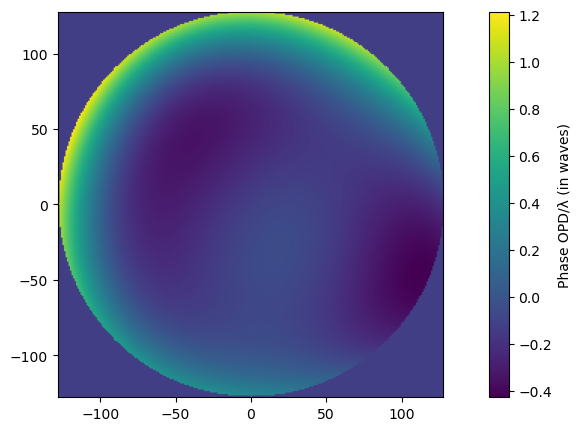

In [5]:
 # Quick plots
extent = [fx[0], fx[-1], fx[0], fx[-1]] 
plt.figure(figsize=(12, 5))
plt.imshow(phi_waves, origin="lower", extent=extent)
plt.colorbar(label='Phase OPD/λ (in waves)')

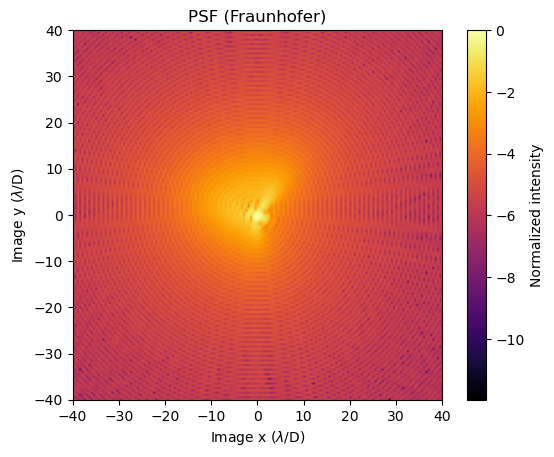

In [6]:
plt.figure()
plt.imshow(np.log10(I), origin="lower", cmap="inferno", extent=extent)
plt.colorbar(label="Normalized intensity")
plt.title('PSF (Fraunhofer)')
plt.xlabel(r"Image x ($\lambda$/D)")
plt.xlim(-40, 40)
plt.ylim(-40, 40)
plt.ylabel(r"Image y ($\lambda$/D)"
        )
plt.show()

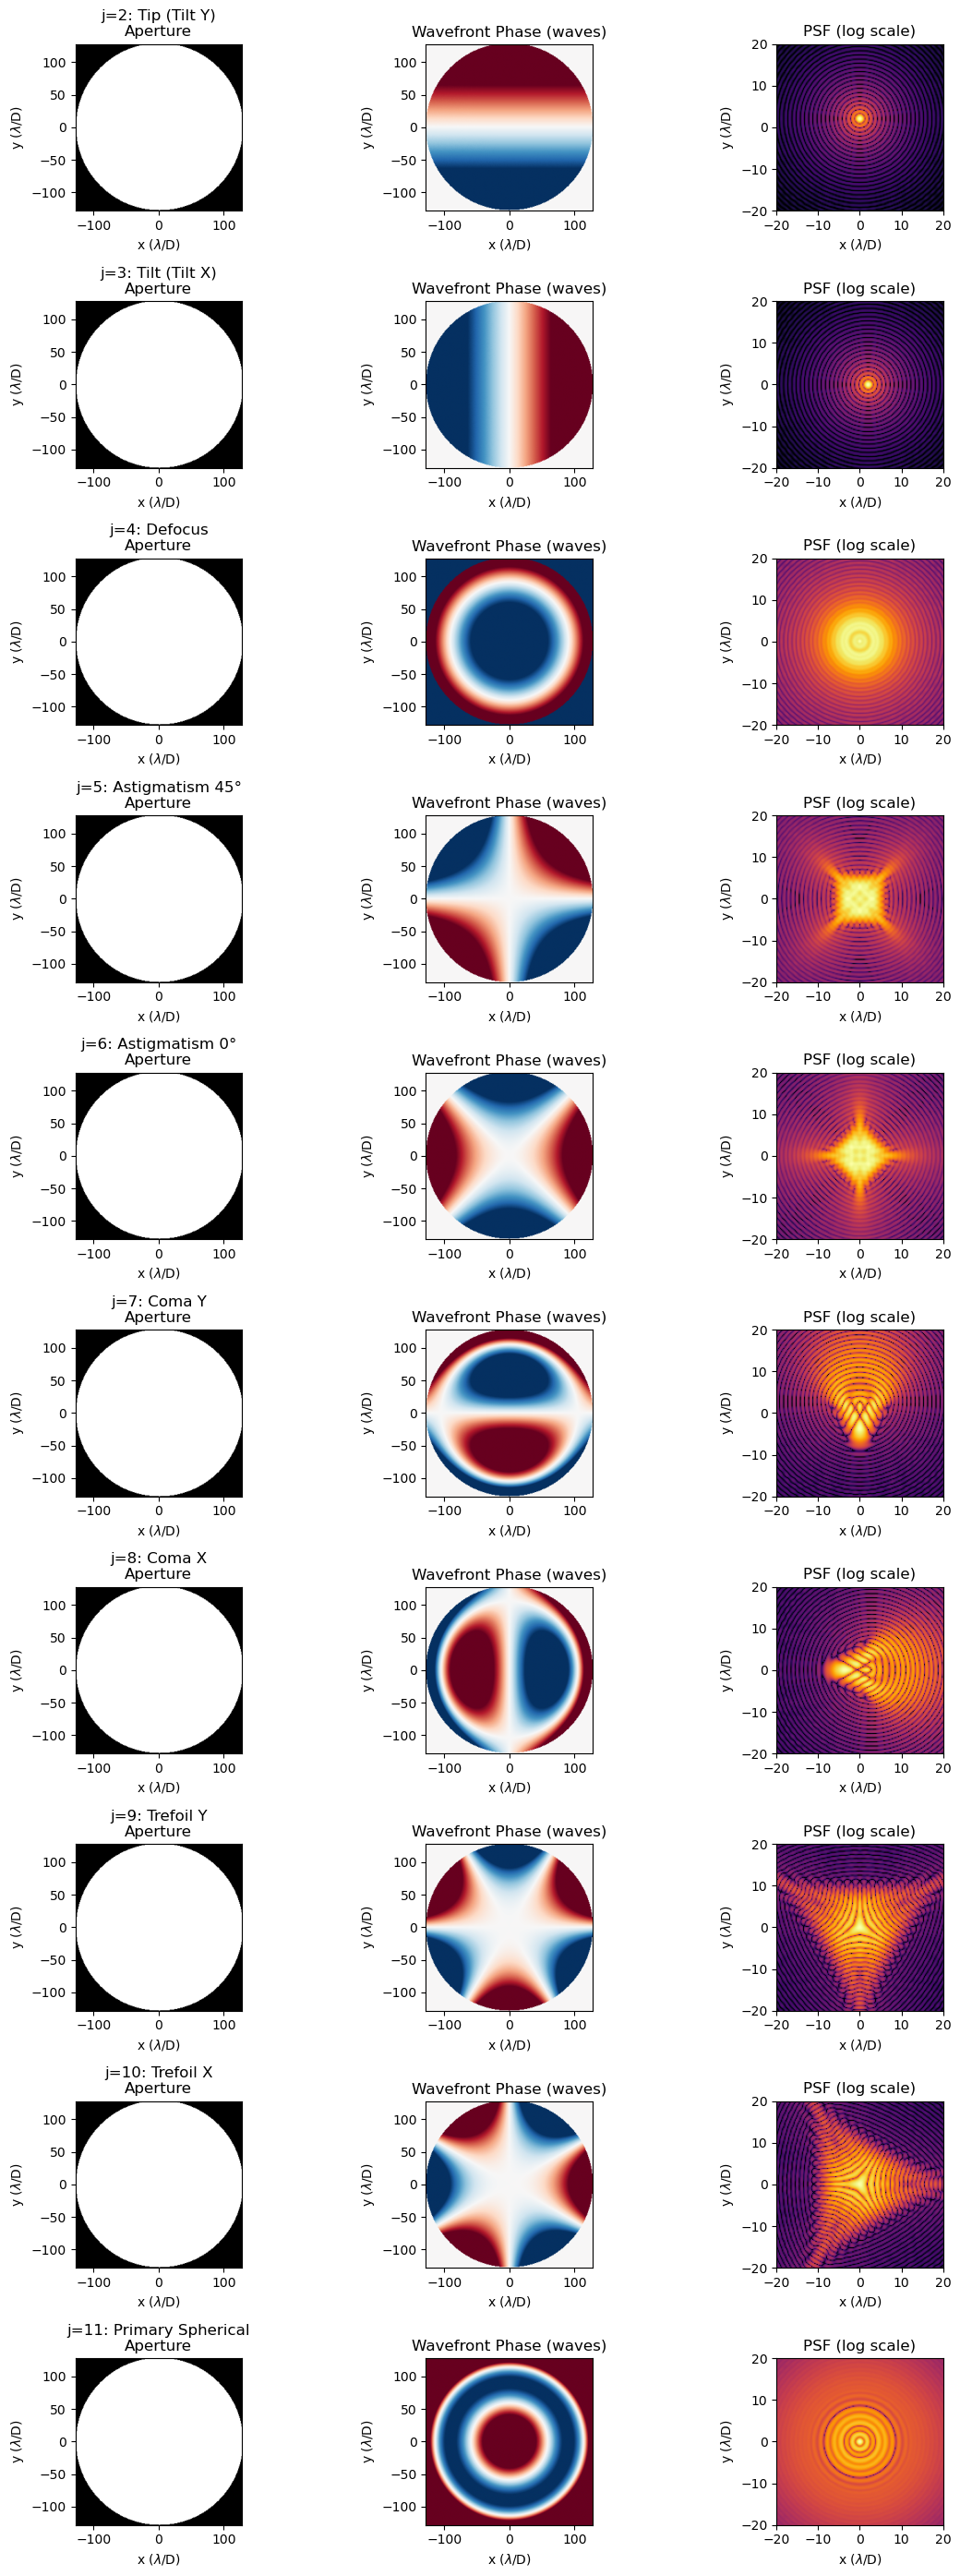

In [7]:
# Make a grid of all the individual Zernike modes for j=2..11
zernike_names = {
    2: 'Tip (Tilt Y)',
    3: 'Tilt (Tilt X)', 
    4: 'Defocus',
    5: 'Astigmatism 45°',
    6: 'Astigmatism 0°',
    7: 'Coma Y',
    8: 'Coma X',
    9: 'Trefoil Y',
    10: 'Trefoil X',
    11: 'Primary Spherical'
}

fig, axes = plt.subplots(10, 3, figsize=(12, 28))

for idx, j in enumerate(range(2, 12)): 
    coeffs = {j: 0.5}  # 0.2 waves amplitude for visibility
    fx, I, pupil, phi_waves, coeffs_used = psf_from_zernikes(
        N=256,
        coeffs_waves=coeffs,
        pad_factor=4,
        normalize="peak",
    )
    
    extent = [fx[0], fx[-1], fx[0], fx[-1]]
    
    # Plot aperture
    axes[idx, 0].imshow(np.abs(pupil), origin="lower", cmap='gray', extent=extent)
    axes[idx, 0].set_title(f'j={j}: {zernike_names[j]}\nAperture')
    axes[idx, 0].set_xlabel(r'x ($\lambda$/D)')
    axes[idx, 0].set_ylabel(r'y ($\lambda$/D)')
    
    # Plot phase
    axes[idx, 1].imshow(phi_waves, origin="lower", cmap='RdBu_r', extent=extent, vmin=-0.5, vmax=0.5)
    axes[idx, 1].set_title('Wavefront Phase (waves)')
    axes[idx, 1].set_xlabel(r'x ($\lambda$/D)')
    axes[idx, 1].set_ylabel(r'y ($\lambda$/D)')
    
    # Plot PSF (log scale)
    axes[idx, 2].imshow(np.log10(I), origin="lower", cmap='inferno', extent=extent, vmin=-6, vmax=0)
    axes[idx, 2].set_title('PSF (log scale)')
    axes[idx, 2].set_xlabel(r'x ($\lambda$/D)')
    axes[idx, 2].set_ylabel(r'y ($\lambda$/D)')
    axes[idx, 2].set_xlim(-20, 20)
    axes[idx, 2].set_ylim(-20, 20)

plt.tight_layout()
plt.show()

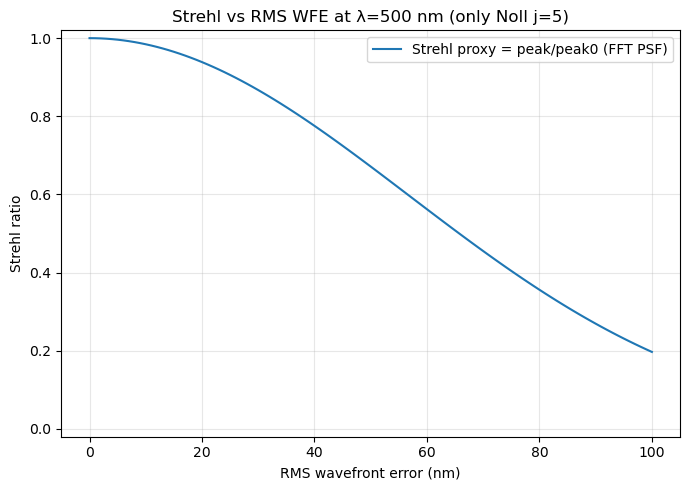

Strehl at 0 nm: 1.0
Strehl at 100 nm: 0.19700683337115338


In [11]:
import numpy as np
import matplotlib.pyplot as plt

# --- Assumes these already exist from your framework ---
# psf_from_zernikes(N=..., coeffs_waves=..., pad_factor=..., normalize=...)
# and that zernike_noll() uses Noll-orthonormal normalization (as in the earlier code).

# Parameters
lambda_nm = 500.0
rms_nm = np.linspace(0.0, 100.0, 101)

N = 256
pad_factor = 8  # -> λ/(2D) sampling

# Unaberrated peak
fx0, I0, pupil0, phi0, coeffs0 = psf_from_zernikes(
    N=N,
    coeffs_waves={},      # no aberrations
    pad_factor=pad_factor,
    normalize=None        # IMPORTANT: don't normalize per-image, we want true peak ratios
)
peak0 = I0.max()

# Aberrated peaks for j=5 only
strehl_proxy = np.zeros_like(rms_nm, dtype=float)

for i, sigma_nm in enumerate(rms_nm):
    a5_waves = sigma_nm / lambda_nm  # RMS(OPD)/λ in waves, since RMS(Z5)=1

    coeffs = {5: a5_waves}  # ONLY j=5 astigmatism
    fx, I, pupil, phi_waves, coeffs_used = psf_from_zernikes(
        N=N,
        coeffs_waves=coeffs,
        pad_factor=pad_factor,
        normalize=None
    )
    strehl_proxy[i] = I.max() / peak0

# Maréchal approximation for comparison
sigma_waves = rms_nm / lambda_nm
strehl_marechal = np.exp(-(2*np.pi*sigma_waves)**2)

# Plot
plt.figure(figsize=(7,5))
plt.plot(rms_nm, strehl_proxy, label="Strehl proxy = peak/peak0 (FFT PSF)")
#plt.plot(rms_nm, strehl_marechal, "--", label="Maréchal exp(-(2πσ/λ)^2)")
plt.xlabel("RMS wavefront error (nm)")
plt.ylabel("Strehl ratio")
plt.title("Strehl vs RMS WFE at λ=500 nm (only Noll j=5)")
plt.ylim(-0.02, 1.02)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print("Strehl at 0 nm:", strehl_proxy[0])
print("Strehl at 100 nm:", strehl_proxy[-1])


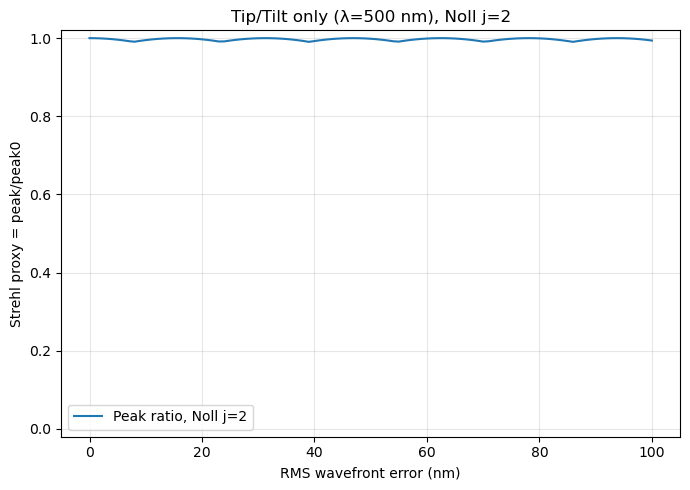

At 100 nm RMS:
  uncorrected: 0.9938521890517051
  TT-removed : 0.9938521890517051


In [12]:
# Repeat above fut for tilt: 
import numpy as np
import matplotlib.pyplot as plt

lambda_nm = 500.0
rms_nm = np.linspace(0.0, 100.0, 101)

N = 256
pad_factor = 8  # λ/(2D) sampling
j_tip = 2       # choose 3 for "x-tilt" (or 2 for "y-tilt")

# Unaberrated reference peak
_, I0, *_ = psf_from_zernikes(
    N=N, coeffs_waves={}, pad_factor=pad_factor, normalize=None
)
peak0 = I0.max()

def recenter_image(I):
    """Shift PSF so its maximum is at the array center."""
    ny, nx = I.shape
    cy, cx = ny//2, nx//2
    iy, ix = np.unravel_index(np.argmax(I), I.shape)
    return np.roll(np.roll(I, cy - iy, axis=0), cx - ix, axis=1)

strehl_uncorrected = np.zeros_like(rms_nm, dtype=float)
strehl_tt_removed  = np.zeros_like(rms_nm, dtype=float)

for i, sigma_nm in enumerate(rms_nm):
    a_tip_waves = sigma_nm / lambda_nm  # RMS(OPD)/λ in waves

    coeffs = {j_tip: a_tip_waves}  # only tip/tilt term
    _, I, *_ = psf_from_zernikes(
        N=N, coeffs_waves=coeffs, pad_factor=pad_factor, normalize=None
    )

    # 1) "uncorrected" peak ratio (max anywhere in the frame)
    strehl_uncorrected[i] = I.max() / peak0

    # 2) TT-removed: recenter PSF, then take peak ratio
    I_centered = recenter_image(I)
    strehl_tt_removed[i] = I_centered.max() / peak0

# Maréchal approximation is NOT appropriate for pure tip/tilt as "aberration"
# in the usual Strehl sense (since it is removable), so we omit it here.

plt.figure(figsize=(7,5))
plt.plot(rms_nm, strehl_uncorrected, label=f"Peak ratio, Noll j={j_tip}")
#plt.plot(rms_nm, strehl_tt_removed, "--", label="Peak ratio after recenter (TT removed)")
plt.xlabel("RMS wavefront error (nm)")
plt.ylabel("Strehl proxy = peak/peak0")
plt.title(f"Tip/Tilt only (λ=500 nm), Noll j={j_tip}")
plt.ylim(-0.02, 1.02)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print("At 100 nm RMS:")
print("  uncorrected:", strehl_uncorrected[-1])
print("  TT-removed :", strehl_tt_removed[-1])


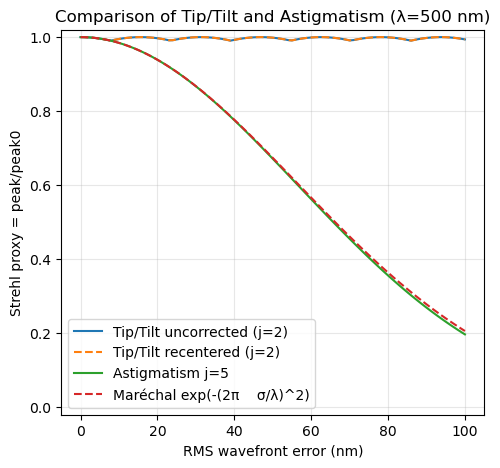

In [10]:
# Plot tip/tilt and astigm on the same plot for comparison
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(rms_nm, strehl_uncorrected, label=f"Tip/Tilt uncorrected (j={j_tip})")
plt.plot(rms_nm, strehl_tt_removed, "--", label=f"Tip/Tilt recentered (j={j_tip})")
plt.plot(rms_nm, strehl_proxy, label="Astigmatism j=5")
plt.plot(rms_nm, strehl_marechal, "--", label="Maréchal exp(-(2π    σ/λ)^2)")
plt.xlabel("RMS wavefront error (nm)")
plt.ylabel("Strehl proxy = peak/peak0")
plt.title(f"Comparison of Tip/Tilt and Astigmatism (λ=500 nm)")
plt.ylim(-0.02, 1.02)
plt.grid(True, alpha=0.3)
plt.legend()

tip and tilt do not intrinsically degrade image quality 

In [169]:
import numpy as np

# Given / your parameters
D = 8.0      # meters
r_0 = 0.1    # meters (at the same wavelength)
wl = 500e-9  # meters (not directly needed if r0 already corresponds to wl)

post_factor = (D / r_0)**(5/3)

# Your variance coefficients (Noll-style; interpret as radians^2 coefficient multipliers)
variances_coeffs = {
    1: 1.0299,  # piston (usually ignored for imaging)
    2: 0.582,   # tip/tilt etc (depends on your indexing choice; keep as you defined)
    3: 0.134,
    4: 0.111,
    5: 0.0880,
    6: 0.0648,
    7: 0.05
}

def draw_atmospheric_zernikes(
    variances_coeffs,
    post_factor,
    rng=None,
    include_piston=False,
    remove_tilt=False,
):
    """
    Draw Zernike coefficients a_j in *waves* assuming:
      Var(a_j [radians]) = variances_coeffs[j] * post_factor

    Returns dict coeffs_waves {j: a_j_waves}.
    """
    rng = np.random.default_rng() if rng is None else rng
    coeffs_waves = {}

    for j, c_j in variances_coeffs.items():
        if (j == 1) and (not include_piston):
            continue

        sigma_rad = np.sqrt(c_j * post_factor)        # radians
        a_rad = rng.normal(0.0, sigma_rad)            # radians
        a_waves = a_rad / (2*np.pi)                   # waves
        coeffs_waves[j] = a_waves

    if remove_tilt:
        # If your dictionary keys 2 and 3 correspond to tip/tilt in your scheme,
        # set them to zero to simulate ideal TT correction.
        coeffs_waves.pop(2, None)
        coeffs_waves.pop(3, None)

    return coeffs_waves

# Example: generate one atmospheric realization and a PSF
rng = np.random.default_rng(123)

coeffs_waves = draw_atmospheric_zernikes(
    variances_coeffs=variances_coeffs,
    post_factor=post_factor,
    rng=rng,
    include_piston=False,
    remove_tilt=False,   # set True if you want "after tip/tilt correction"
)

fx, I, pupil, phi_waves, coeffs_used = psf_from_zernikes(
    N=256,
    coeffs_waves=coeffs_waves,
    pad_factor=2,     # λ/(2D) sampling as before
    normalize="peak"  # OK for display; for Strehl do normalize=None and compare peaks
)

print("Drawn atmospheric coefficients (waves):")
for j in sorted(coeffs_used.keys()):
    print(f"  j={j}: {coeffs_used[j]: .5e}")


Drawn atmospheric coefficients (waves):
  j=2: -4.62849e+00
  j=3: -8.25804e-01
  j=4:  2.63197e+00
  j=5:  3.52951e-01
  j=6:  1.43685e+00
  j=7:  7.91530e-01


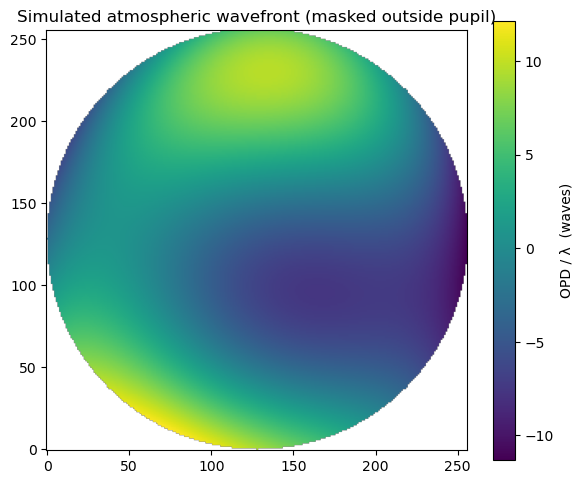

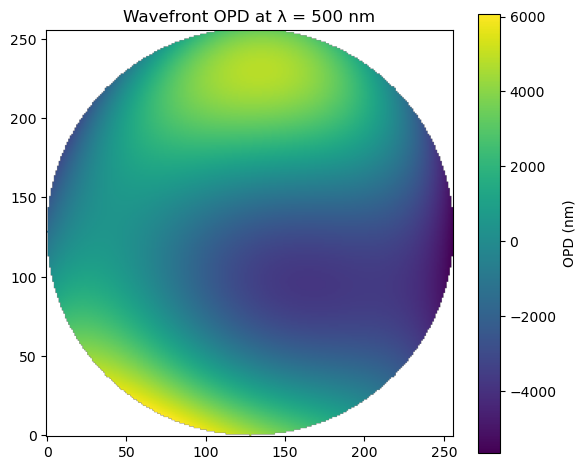

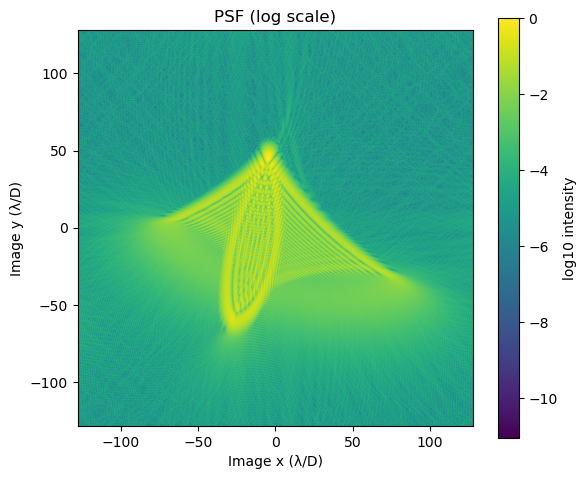

Drawn coefficients (waves):
  j= 2:  1.426e+00
  j= 3: -2.335e+00
  j= 4:  1.534e+00
  j= 5:  1.711e+00
  j= 6: -3.046e+00
  j= 7: -1.935e+00
  j= 8:  1.797e-01
  j= 9: -4.174e-01
  j=10: -2.064e-02
  j=11: -1.016e+00
RMS OPD: 5.197 waves  = 2598.4 nm at 500 nm


In [175]:
import numpy as np
import matplotlib.pyplot as plt

# ---- Your parameters ----
D = 8.0      # m
r_0 = 0.1    # m
wl = 500e-9  # m  (imaging wavelength)

post_factor = (D / r_0)**(5/3)

variances_coeffs = {
    1: 1.0299,
    2: 0.582,
    3: 0.134,
    4: 0.111,
    5: 0.0880,
    6: 0.0648,
    7: 0.0587,
    8: 0.0525,
    9: 0.0463,
    10: 0.0401, 
    11: 0.0377
}

# ---- One random atmospheric realization ----
rng = np.random.default_rng(42)

coeffs_waves = draw_atmospheric_zernikes(
    variances_coeffs=variances_coeffs,
    post_factor=post_factor,
    rng=rng,
    include_piston=False,
    remove_tilt=False,   # set True if you want "after TT correction"
)

# ---- Compute PSF + wavefront using your framework ----
fx, I, pupil, phi_waves, coeffs_used = psf_from_zernikes(
    N=256,
    coeffs_waves=coeffs_waves,
    pad_factor=8,        # λ/(2D) sampling
    normalize="peak"     # good for display; use None if doing peak-ratio Strehl
)

# ---- Make some useful derived arrays ----
mask = (np.abs(pupil) > 0)  # aperture mask
phi_waves_masked = np.where(mask, phi_waves, np.nan)

# Convert OPD from waves -> nm (OPD = phi_waves * λ)
phi_nm_masked = phi_waves_masked * (wl * 1e9)

# Helpful PSF plotting extents in λ/D units
extent = [fx[0], fx[-1], fx[0], fx[-1]]

# ---- Plot wavefront (waves) ----
plt.figure(figsize=(6,5))
plt.imshow(phi_waves_masked, origin="lower")
plt.colorbar(label="OPD / λ  (waves)")
plt.title("Simulated atmospheric wavefront (masked outside pupil)")
plt.tight_layout()

# ---- Plot wavefront (nm OPD) ----
plt.figure(figsize=(6,5))
plt.imshow(phi_nm_masked, origin="lower")
plt.colorbar(label="OPD (nm)")
plt.title(f"Wavefront OPD at λ = {wl*1e9:.0f} nm")
plt.tight_layout()


# ---- Plot PSF (log scale, zoomed) ----
plt.figure(figsize=(6,5))
plt.imshow(np.log10(I + 1e-12), origin="lower", extent=extent)
plt.colorbar(label="log10 intensity")
plt.title("PSF (log scale)")
plt.xlabel("Image x (λ/D)")
plt.ylabel("Image y (λ/D)")
plt.tight_layout()

plt.show()

# ---- Print a quick summary ----
phi_rms_waves = np.nanstd(phi_waves_masked)
phi_rms_nm = phi_rms_waves * (wl * 1e9)
print("Drawn coefficients (waves):")
for j in sorted(coeffs_used):
    print(f"  j={j:2d}: {coeffs_used[j]: .3e}")
print(f"RMS OPD: {phi_rms_waves:.3f} waves  = {phi_rms_nm:.1f} nm at {wl*1e9:.0f} nm")


In [ ]:
# redo the draw 


In [177]:
n_realizations = 1000

rng = np.random.default_rng(123)

# Precompute coordinate extent for plotting
fx, I0, *_ = psf_from_zernikes(N=N, coeffs_waves={}, pad_factor=pad_factor, normalize=None)
extent = [fx[0], fx[-1], fx[0], fx[-1]]

# Accumulate (long-exposure) PSF
I_sum = None

for k in range(n_realizations):
    coeffs_waves = draw_atmospheric_zernikes(
        variances_coeffs=variances_coeffs,
        post_factor=post_factor,
        rng=rng,
        include_piston=False,
        remove_tilt=False,   # set True to see TT-corrected long exposure
    )

    _, I, *_ = psf_from_zernikes(
        N=N,
        coeffs_waves=coeffs_waves,
        pad_factor=pad_factor,
        normalize=None      # IMPORTANT: don't renormalize each realization
    )

    if I_sum is None:
        I_sum = I.copy()
    else:
        I_sum += I

# Normalize the summed PSF for display (peak = 1)
I_long = I_sum / I_sum.max()

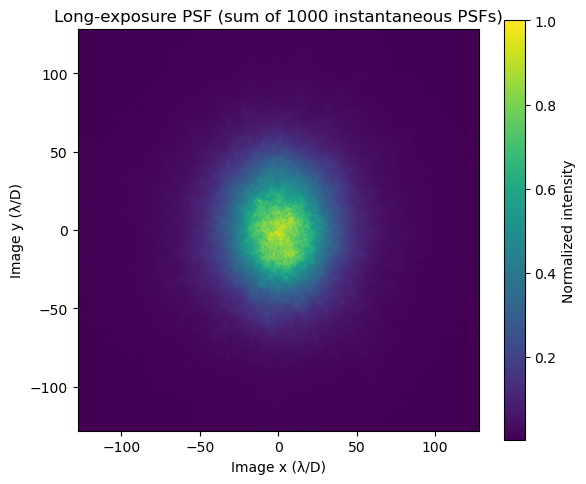

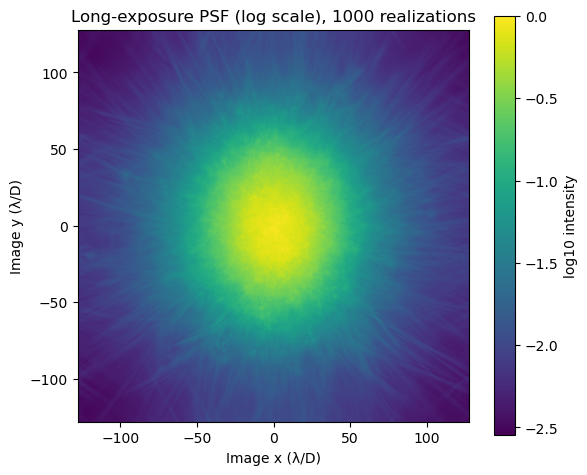

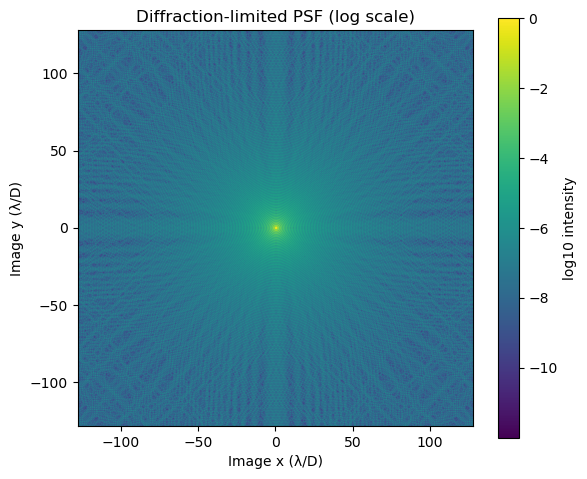

In [ ]:
# ---- Plot long exposure PSF ----
plt.figure(figsize=(6,5))
plt.imshow(I_long, origin="lower", extent=extent)
plt.colorbar(label="Normalized intensity")
plt.title(f"Long-exposure PSF (sum of {n_realizations} instantaneous PSFs)")
plt.xlabel("Image x (λ/D)")
plt.ylabel("Image y (λ/D)")
plt.tight_layout()

plt.figure(figsize=(6,5))
plt.imshow(np.log10(I_long + 1e-12), origin="lower", extent=extent)
plt.colorbar(label="log10 intensity")
plt.title(f"Long-exposure PSF (log scale), {n_realizations} realizations")
plt.xlabel("Image x (λ/D)")
plt.ylabel("Image y (λ/D)")
plt.xlim()
plt.tight_layout()

plt.show()

# Optional: compare to diffraction-limited PSF on same grid
_, I_dl, *_ = psf_from_zernikes(N=N, coeffs_waves={}, pad_factor=pad_factor, normalize=None)
I_dl = I_dl / I_dl.max()

plt.figure(figsize=(6,5))
plt.imshow(np.log10(I_dl + 1e-12), origin="lower", extent=extent)
plt.colorbar(label="log10 intensity")
plt.title("Diffraction-limited PSF (log scale)")
plt.xlabel("Image x (λ/D)")
plt.ylabel("Image y (λ/D)")
plt.tight_layout()
plt.show()
